# **Retail Sales Analysis Using Python (Pandas)**

The objective of this project is to analyze sales data and identify trends in revenue, customer behavior, product performance, and deal sizes.

📊 **Sales Overview**
1. What is total sales over time?
2. Which months/years have highest sales?
3. Which products generate highest revenue?

👤 **Customer Insight**
1. Which countries generate most sales?
2. Which customers contribute most revenue?

📦 **Order Behavior**
1. What is the distribution of deal sizes?

## **Import Libraries & Loading Dataset**
Describe: Loaded the sales dataset into a pandas DataFrame.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/Sales Data.csv", encoding='latin1')

## **Data Exploration**
Describe: Examined the structure, columns, data types, and summary statistics of the dataset.

In [5]:
df.head()

,ORDER NUMBER,QUANTITY ORDERED,PRICE EACH,ORDER LINE NUMBER,SALES,ORDER DATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESS LINE1,ADDRESS LINE2,CITY,STATE,POSTAL CODE,COUNTRY,TERRITORY,CONTACT LAST NAME,CONTAC TFIRST NAME,DEAL SIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ORDER NUMBER        2823 non-null   int64  
 1   QUANTITY ORDERED    2823 non-null   int64  
 2   PRICE EACH          2823 non-null   float64
 3   ORDER LINE NUMBER   2823 non-null   int64  
 4   SALES               2823 non-null   float64
 5   ORDER DATE          2823 non-null   object 
 6   STATUS              2823 non-null   object 
 7   QTR_ID              2823 non-null   int64  
 8   MONTH_ID            2823 non-null   int64  
 9   YEAR_ID             2823 non-null   int64  
 10  PRODUCT LINE        2823 non-null   object 
 11  MSRP                2823 non-null   int64  
 12  PRODUCT CODE        2823 non-null   object 
 13  CUSTOMER NAME       2823 non-null   object 
 14  PHONE               2823 non-null   object 
 15  ADDRESS LINE1       2823 non-null   object 
 16  ADDRES

In [7]:
df.describe()

,ORDER NUMBER,QUANTITY ORDERED,PRICE EACH,ORDER LINE NUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [8]:
df.columns

Index(['ORDER NUMBER', 'QUANTITY ORDERED', 'PRICE EACH', 'ORDER LINE NUMBER',
       'SALES', 'ORDER DATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCT LINE', 'MSRP', 'PRODUCT CODE', 'CUSTOMER NAME', 'PHONE',
       'ADDRESS LINE1', 'ADDRESS LINE2', 'CITY', 'STATE', 'POSTAL CODE',
       'COUNTRY', 'TERRITORY', 'CONTACT LAST NAME', 'CONTAC TFIRST NAME',
       'DEAL SIZE'],
      dtype='object')

In [9]:
df.shape

(2823, 25)

## **Data Cleaning**
Describe: Checked for missing values and removed irrelevant columns that were not required for the analysis.

In [10]:
df.isnull().sum()

,0
ORDER NUMBER,0
QUANTITY ORDERED,0
PRICE EACH,0
ORDER LINE NUMBER,0
SALES,0
ORDER DATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [11]:
df = df.drop(columns=["ADDRESS LINE2", "STATE", "POSTAL CODE", "TERRITORY"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ORDER NUMBER        2823 non-null   int64  
 1   QUANTITY ORDERED    2823 non-null   int64  
 2   PRICE EACH          2823 non-null   float64
 3   ORDER LINE NUMBER   2823 non-null   int64  
 4   SALES               2823 non-null   float64
 5   ORDER DATE          2823 non-null   object 
 6   STATUS              2823 non-null   object 
 7   QTR_ID              2823 non-null   int64  
 8   MONTH_ID            2823 non-null   int64  
 9   YEAR_ID             2823 non-null   int64  
 10  PRODUCT LINE        2823 non-null   object 
 11  MSRP                2823 non-null   int64  
 12  PRODUCT CODE        2823 non-null   object 
 13  CUSTOMER NAME       2823 non-null   object 
 14  PHONE               2823 non-null   object 
 15  ADDRESS LINE1       2823 non-null   object 
 16  CITY  

## **Understanding Dataset**

Explored unique categories and business dimensions within the dataset.

In [13]:
df["COUNTRY"].nunique()

19

In [14]:
df["COUNTRY"].unique()

array(['USA', 'France', 'Norway', 'Australia', 'Finland', 'Austria', 'UK',
       'Spain', 'Sweden', 'Singapore', 'Canada', 'Japan', 'Italy',
       'Denmark', 'Belgium', 'Philippines', 'Germany', 'Switzerland',
       'Ireland'], dtype=object)

In [15]:
df["PRODUCT LINE"].nunique()

7

In [16]:
df["PRODUCT LINE"].unique()

array(['Motorcycles', 'Classic Cars', 'Trucks and Buses', 'Vintage Cars',
       'Planes', 'Ships', 'Trains'], dtype=object)

In [17]:
df["DEAL SIZE"].unique()

array(['Small', 'Medium', 'Large'], dtype=object)

In [18]:
df["STATUS"].value_counts()

,count
STATUS,
Shipped,2617
Cancelled,60
Resolved,47
On Hold,44
In Process,41
Disputed,14


## **Answer Business Questions:**

**📊 Sales Overview**

**1. Total Sales Over Years**

In [19]:
df.groupby("YEAR_ID")["SALES"].sum()

,SALES
YEAR_ID,
2003,3516979.54
2004,4724162.60
2005,1791486.71


**Analysis:** Sales increased from 3.52 million dollars in 2003 to 4.72 million dollars in 2004, making 2004 the highest-performing year in the dataset. Sales then dropped to $1.79 million in 2005. Although 2005 shows lower figures, the dataset contains only part of the year, so the decline should not be interpreted as reduced business performance without further analysis.

**2. Total Quantity Ordered Over Years**

In [20]:
df.groupby("YEAR_ID")["QUANTITY ORDERED"].sum()

,QUANTITY ORDERED
YEAR_ID,
2003,34612
2004,46824
2005,17631


**Analysis:** The total quantity ordered increased from 34,612 units in 2003 to 46,824 units in 2004, indicating stronger sales volume and customer demand. In 2005, the quantity ordered decreased to 17,631 units. This pattern is consistent with the sales revenue trend, where 2004 was the strongest year in terms of both revenue and units sold.

**3. Total Sales Over Months**

In [21]:
df.groupby("MONTH_ID")["SALES"].sum()

,SALES
MONTH_ID,
1,785874.44
2,810441.90
3,754501.39
4,669390.96
5,923972.56
6,454756.78
7,514875.97
8,659310.57
9,584724.27


**Analysis:** November recorded the highest sales revenue at 2.12 million dollars, significantly outperforming all other months. October was the second strongest month with 1.12 million dollars in sales. In contrast, June generated the lowest revenue at 454,757 dollars. The strong performance during October and November suggests a seasonal increase in demand toward the end of the year.

**4. Total Quantity Ordered Over Months**

In [22]:
df.groupby("MONTH_ID")["QUANTITY ORDERED"].sum()

,QUANTITY ORDERED
MONTH_ID,
1,7997
2,7903
3,7585
4,6704
5,8992
6,4620
7,4899
8,6538
9,5681


**Analysis:** November recorded the highest order volume with 20,857 units sold, nearly double the quantity sold in October (10,998 units), the second-highest month. June had the lowest order volume with 4,620 units sold. The quantity ordered closely follows the sales revenue trend, suggesting that revenue growth is primarily driven by increased demand and order volume rather than pricing changes.

**5. Total Sales Per Each Product Line**

In [23]:
df.groupby("PRODUCT LINE")["SALES"].sum()

,SALES
PRODUCT LINE,
Classic Cars,3919615.66
Motorcycles,1166388.34
Planes,975003.57
Ships,714437.13
Trains,226243.47
Trucks and Buses,1127789.84
Vintage Cars,1903150.84


**Analysis:** Classic Cars generated the highest revenue, contributing 3.92 million dollars in sales, making it the most profitable product line in the dataset. Vintage Cars ranked second with 1.90 million dollars in revenue. In contrast, Trains generated the lowest revenue at 226,243 dollars, indicating relatively low sales performance compared to other product categories.

**6. Total Quantity Ordered Per Each Product Line**

In [24]:
df.groupby("PRODUCT LINE")["QUANTITY ORDERED"].sum()

,QUANTITY ORDERED
PRODUCT LINE,
Classic Cars,33992
Motorcycles,11663
Planes,10727
Ships,8127
Trains,2712
Trucks and Buses,10777
Vintage Cars,21069


**Analysis:** Classic Cars was the strongest-performing product line, generating 3.92 million dollars in revenue from 33,992 units sold. It led both revenue and order volume, indicating consistently high customer demand. Vintage Cars ranked second, producing 1.90 million dollars in sales from 21,069 units ordered. On the other end, Trains generated the lowest revenue (226,243 dollars) and the fewest units sold (2,712), suggesting relatively low demand compared to other product categories. Overall, the product lines with the highest sales revenue also recorded the highest order quantities, indicating a strong relationship between demand volume and revenue generation.

**👤 Customer Insight**

**1. Total Sales Per Country**

In [25]:
df.groupby("COUNTRY")["SALES"].sum()

,SALES
COUNTRY,
Australia,630623.10
Austria,202062.53
Belgium,108412.62
Canada,224078.56
Denmark,245637.15
Finland,329581.91
France,1110916.52
Germany,220472.09
Ireland,57756.43


**Analysis:** Revenue is heavily concentrated in the USA, Spain, and France. The USA represents the company's most important market, while several smaller markets contribute only a limited share of overall sales. This concentration suggests that future growth opportunities may lie either in strengthening high-performing markets or expanding sales in underperforming regions.

**2. Highest & Lowest Sales Countries**

In [26]:
country_sales = df.groupby("COUNTRY")["SALES"].sum()

print("Highest sales country:", country_sales.idxmax())
print("Sales:", country_sales.max())

print("Lowest sales country:", country_sales.idxmin())
print("Sales:", country_sales.min())

Highest sales country: USA
Sales: 3627982.83
Lowest sales country: Ireland
Sales: 57756.43


**Analysis:** The USA was the dominant market with 3.63 million dollars in sales, while Ireland contributed the least revenue at 57,756 dollars. This highlights a significant difference in market performance across countries.

**3. Highest To Lowest Sales Countries**

In [27]:
country_sales.sort_values(ascending=False)

,SALES
COUNTRY,
USA,3627982.83
Spain,1215686.92
France,1110916.52
Australia,630623.10
UK,478880.46
Italy,374674.31
Finland,329581.91
Norway,307463.70
Singapore,288488.41


**Analysis:** A noticeable drop appears after the top three countries, with Australia (630K dollars) and the UK (478K dollars) forming the next tier of mid-performing markets.

**4. Sales For Each Customer**

In [28]:
df.groupby("CUSTOMER NAME")["SALES"].sum()

,SALES
CUSTOMER NAME,
"AV Stores, Co.",157807.81
Alpha Cognac,70488.44
Amica Models & Co.,94117.26
"Anna's Decorations, Ltd",153996.13
Atelier graphique,24179.96
...,...
"Vida Sport, Ltd",117713.56
Vitachrome Inc.,88041.26
"Volvo Model Replicas, Co",75754.88


**Analysis:** This section highlights the key customers in the dataset and their contribution to overall sales. It shows that revenue is spread across multiple customers, with some customers contributing more than others. The data helps identify important buyers and understand customer-level sales distribution, which is useful for customer segmentation and targeting strategies.

**5. Highest & Lowest Customer Contribution**

In [29]:
customer_contribution = df.groupby("CUSTOMER NAME")["SALES"].sum()

print("Highest customer contribution:", customer_contribution.idxmax())
print("Sales:", customer_contribution.max())

print("Lowest customer contribution:", customer_contribution.idxmin())
print("Sales:", customer_contribution.min())

Highest customer contribution: Euro Shopping Channel
Sales: 912294.11
Lowest customer contribution: Boards & Toys Co.
Sales: 9129.35


**Analysis:** The presence of a dominant customer such as the Euro Shopping Channel suggests that the business may rely heavily on a few key accounts, while many other customers contribute relatively smaller amounts to overall sales.

**6. Highest To Lowest Customer Contribution**

In [30]:
customer_contribution.sort_values(ascending=False)

,SALES
CUSTOMER NAME,
Euro Shopping Channel,912294.11
Mini Gifts Distributors Ltd.,654858.06
"Australian Collectors, Co.",200995.41
Muscle Machine Inc,197736.94
La Rochelle Gifts,180124.90
...,...
Royale Belge,33440.10
Microscale Inc.,33144.93
Auto-Moto Classics Inc.,26479.26


**Analysis:** The dataset shows that a small group of customers contribute significantly to total sales. Customers such as Euro Shopping Channel, Mini Gifts Distributors Ltd., and Australian Collectors Co. are among the highest contributors to revenue, indicating strong repeat or bulk purchasing behavior. On the other hand, customers like Boards & Toys Co., Atelier graphique, and Auto-Moto Classics Inc. contribute relatively lower sales, highlighting a long tail of smaller customers.

**📦 Order Behavior**

**1. Quantity Ordered Per Each Product Line**

In [31]:
df.groupby("PRODUCT LINE")["QUANTITY ORDERED"].sum()

,QUANTITY ORDERED
PRODUCT LINE,
Classic Cars,33992
Motorcycles,11663
Planes,10727
Ships,8127
Trains,2712
Trucks and Buses,10777
Vintage Cars,21069


**Analysis:** The highest number of units ordered comes from Classic Cars, indicating strong customer demand for this product category. Vintage Cars and Motorcycles also show relatively high order volumes, suggesting consistent interest in collectible and automotive-related products.

**2. Number Of Items For Each Deal Size**

In [32]:
df["DEAL SIZE"].value_counts()

,count
DEAL SIZE,
Medium,1384
Small,1282
Large,157


**Analysis:** The majority of orders fall under the Medium and Small deal size categories, with Medium deals being the most frequent, followed closely by Small deals. Large deals represent a much smaller portion of total orders. This indicates that most customers tend to place moderate or small-sized orders, while high-value large transactions are relatively rare.

**3. Sales For Each Deal Size**

In [33]:
df.groupby("DEAL SIZE")["SALES"].sum()

,SALES
DEAL SIZE,
Large,1302119.26
Medium,6087432.24
Small,2643077.35


**Analysis:** Medium-sized deals generate the highest total revenue, contributing 6.09 million dollars, making them the most important segment in terms of overall sales performance. Small deals also contribute significantly with 2.64 million dollars, showing that lower-value transactions still form a meaningful portion of total revenue. Large deals account for 1.30 million dollars, which is the smallest share of revenue among the three categories. This suggests that the business is not heavily dependent on large transactions, but instead relies on a high volume of medium and small deals. Medium-sized deals dominate both order count and revenue, making them the core driver of business performance.

## **Visualization**

**Sales by Year (Line Chart)**

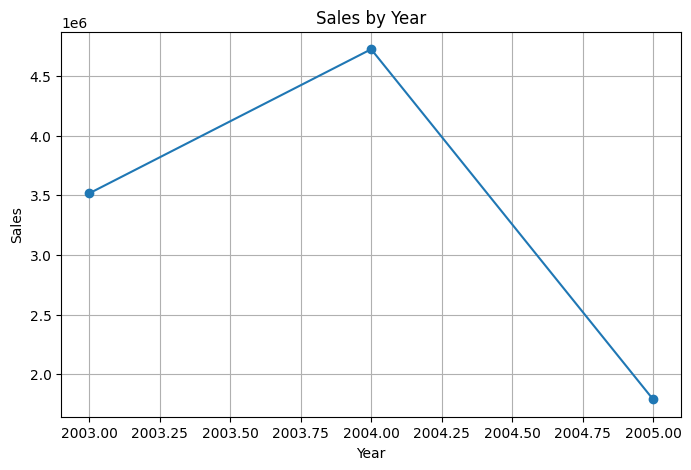

In [34]:
sales_by_year = df.groupby("YEAR_ID")["SALES"].sum()

sales_by_year.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

**Monthly Sales Trend (Line Chart)**

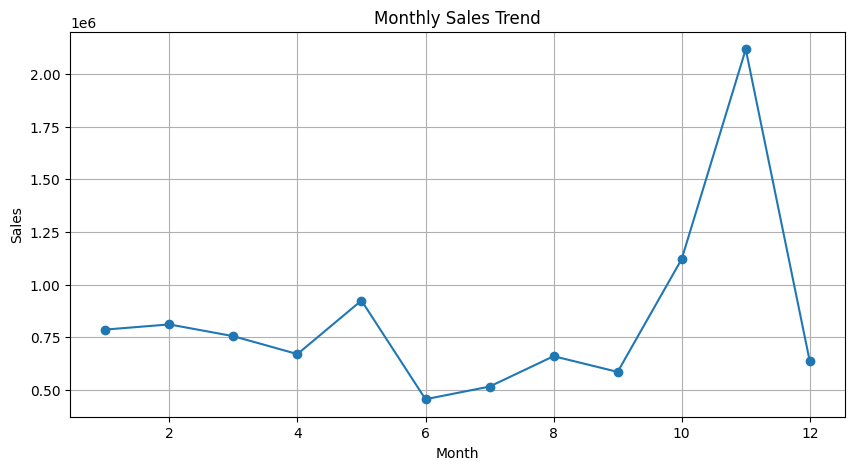

In [35]:
monthly_sales = df.groupby("MONTH_ID")["SALES"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

**Top Product Lines (Bar Chart)**

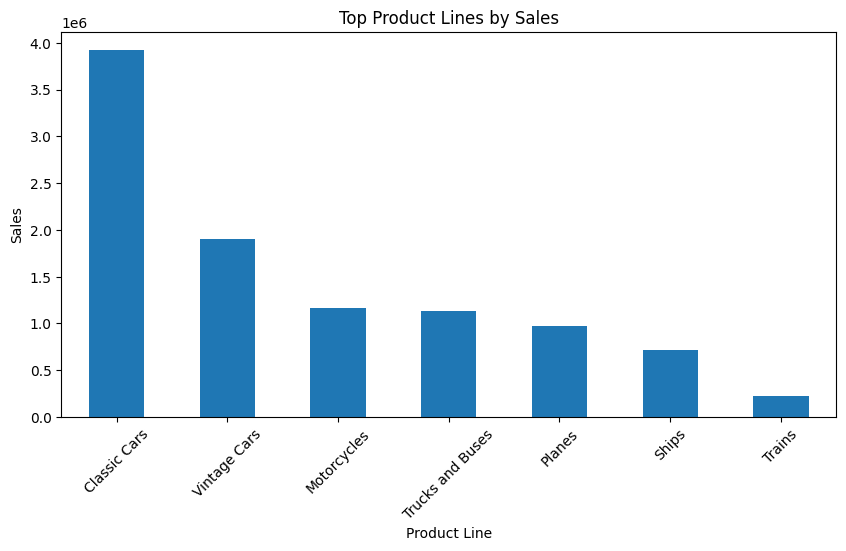

In [36]:
product_sales = df.groupby("PRODUCT LINE")["SALES"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar", figsize=(10,5))
plt.title("Top Product Lines by Sales")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

**Top Countries (Horizontal Bar Chart)**

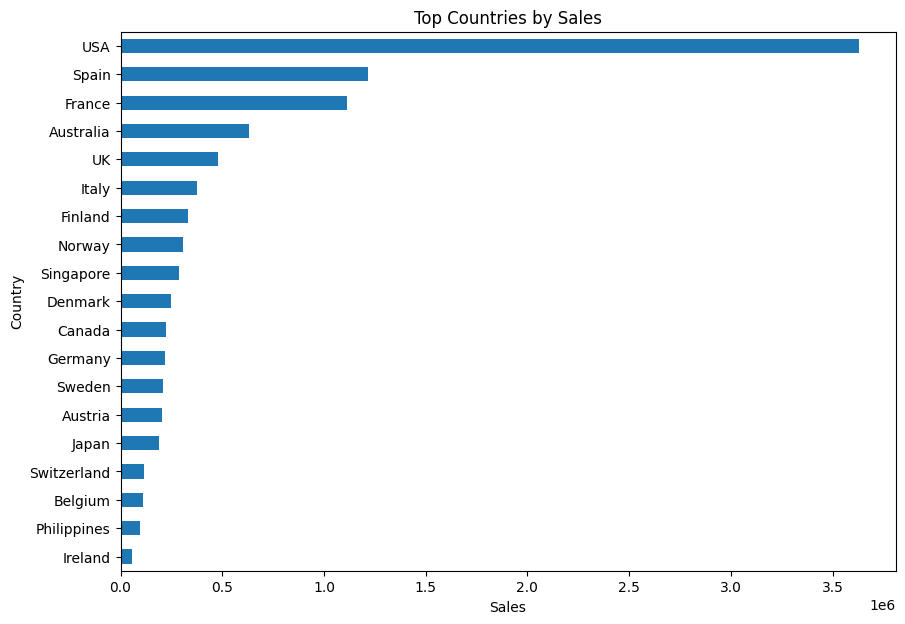

In [37]:
country_sales = df.groupby("COUNTRY")["SALES"].sum().sort_values()

country_sales.plot(kind="barh", figsize=(10,7))
plt.title("Top Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.show()

**Deal Size vs Sales (Pie Chart)**

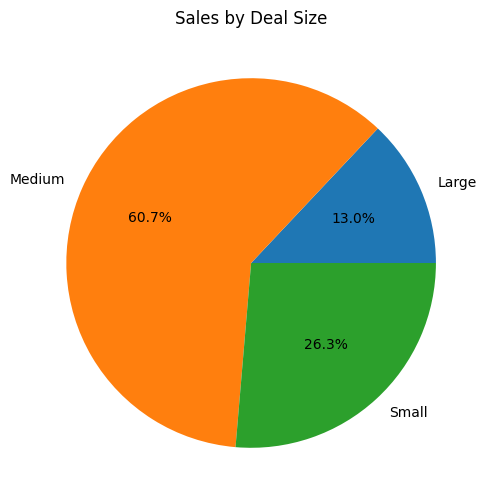

In [38]:
deal_sales = df.groupby("DEAL SIZE")["SALES"].sum()

deal_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Sales by Deal Size")
plt.ylabel("")
plt.show()

# **📌 Key Findings**
a. USA is the top revenue-generating country.

b. Classic Cars is the highest-performing product line.

c. November shows peak sales activity.

d. Medium deals dominate both revenue and order volume.

e. A small number of customers contribute a large share of revenue.